In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Carrega e prepara os dados
data = pd.read_csv("../../Data.csv")
data = data.drop(columns=["VD", "VE", "tempo"])
data.index = (np.arange(0, len(data), 1).astype(float) * 0.07).round(5)

data = data.rename(columns={
    "Setpoint VD": "Wd",
    "Setpoint VE": "We",
    "Theta": "theta(Wd,We)",
    "X": "x(Wd,We)",
    "Y": "y(Wd,We)",
})

In [2]:
import seaborn as sns
from sklearn.preprocessing import StandardScaler

PREDICTORS = ["Wd", "We"]
TARGET = ["theta(Wd,We)"]

def PlotTimeSeries(df, img_name="data.svg", PlotOut=True):    
    # Estilo Seaborn
    sns.set_theme(style="whitegrid")

    # Criando a figura
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plotando Wd e We como linhas
    for preds in PREDICTORS:
        sns.lineplot(x=df.index, y=df[preds], ax=ax1, marker="o", label=preds,  linewidth=2)

    if PlotOut:
        ax2 = ax1.twinx()
        for target in TARGET:
            sns.lineplot(x=df.index, y=df[target], ax=ax2, marker="o", label=target, linestyle="dashed", linewidth=2, color="red")
            ax2.set_ylabel("Posição Angular", fontsize=12, color="gray")

    # Ajustando os rótulos dos eixos
    ax1.set_xlabel("Tempo (s) - Período de amostragem (T=0.07 s)", fontsize=12)
    ax1.set_ylabel("Velocidade Angular", fontsize=12, color="black")

    # Adicionando legendas
    ax1.legend(loc="upper left")
    if PlotOut:
        ax2.legend(loc="upper right")

    # Título
    plt.title("Posição angular em função da velocidade nas rodas", fontsize=14)

    # Exibindo o gráfico
    plt.show()

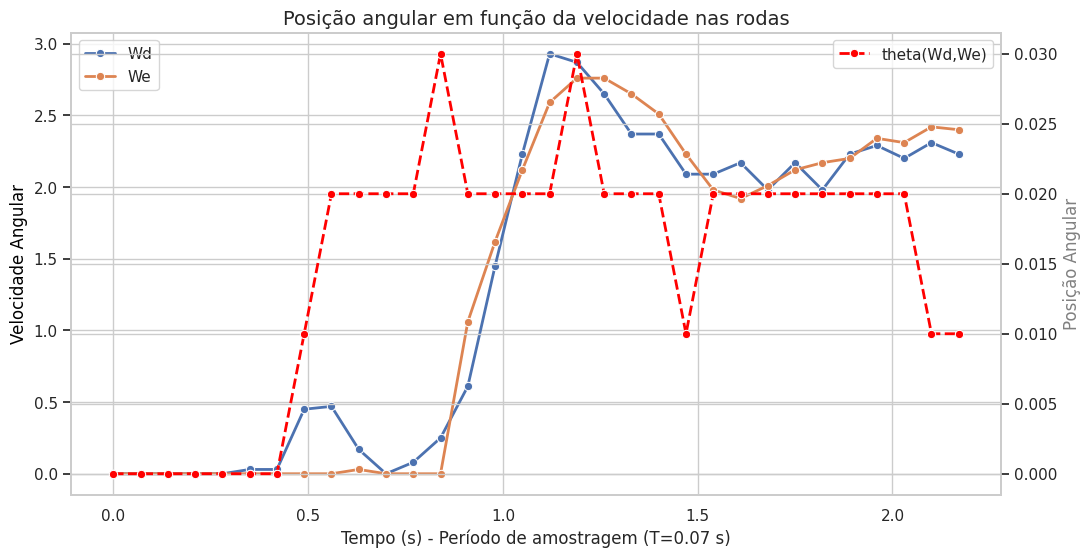

In [3]:
PlotTimeSeries(data.head(32))

In [4]:
PREDICTORS = ["Wd", "We"]
TARGET = "theta(Wd,We)"

def get_XY(data, time_steps, units, output_dim):
    total_samples = (len(data) - time_steps) // time_steps

    X = []
    Y = []
    
    for i in range(total_samples):
        start_idx = i * time_steps
        end_idx = start_idx + time_steps

        X_seq = data.iloc[start_idx:end_idx][PREDICTORS].values  # shape: (time_steps, features)
        Y_target = data.iloc[end_idx][TARGET]  # escalar

        X.append(X_seq)
        Y.append(Y_target)

    X = np.array(X)  # shape: (batch, time_steps, features)
    Y =  Y = np.array(Y).reshape(-1, 1).repeat(output_dim, axis=1)  # shape (batch, output_dim)
    h0 = np.full((X.shape[0], units), fill_value=Y[0]) # shape (batch, units)

    print(f"Shape X (batch, time_steps, features): {X.shape}")
    print(f"Shape Y (batch, output_dim): {Y.shape}")
    print(f"Shape h0 (batch, units): {h0.shape}")
    
    return X, Y, h0

In [5]:
def PlotOut(valuer):
    sns.set_theme(style="whitegrid")

    fig, axs = plt.subplots(3, 1, figsize=(12, 12), sharey=False)

    datasets = [
        ('Treinamento', valuer.train_samples_y, valuer.train_pred),
        ('Validação', valuer.val_samples_y, valuer.val_pred),
        ('Teste', valuer.test_samples_y, valuer.test_pred)
    ]

    times = [
        np.arange(len(valuer.train_samples_y)),
        np.arange(len(valuer.val_samples_y)),
        np.arange(len(valuer.test_samples_y))
    ]

    for i, (title, y_true, y_pred) in enumerate(datasets):
        # Garante que são vetores 1D
        y_true = np.ravel(y_true)
        y_pred = np.ravel(y_pred)

        sns.lineplot(x=times[i], y=y_true, ax=axs[i], marker="o", label="Amostras Reais", linewidth=2)
        sns.lineplot(x=times[i], y=y_pred, ax=axs[i], marker="o", label="Valores preditos", linewidth=2)

        axs[i].set_title(f'{title}')
        axs[i].set_xlabel('Tempo')
        axs[i].set_ylabel('Valor')
        axs[i].legend()
        axs[i].grid(True)

    plt.suptitle('Comparação temporal: Predição (curva) vs Amostras Reais (pontos)')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()  
    
    path = f"./content/models/{valuer.fileName}.png"
    fig.savefig(path)    

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error 
from keras import layers, models, regularizers, initializers, optimizers
from keras.callbacks import EarlyStopping
from itertools import product


class EvalRNN:
    
    def __init__(self, dataset, epochs, time_steps, act_h, act_o):
        self.epochs = epochs
        self.Dataset = dataset
        self.output_dim = np.size(TARGET)
        self.time_steps = time_steps
        self.act_h = act_h
        self.act_o = act_o
        self.better_metrics = {}


    def SplitData(self, units):
        self.units = units
                
        train_data, test_data = train_test_split(self.Dataset, test_size=0.25, shuffle=False)
        train_data, val_data = train_test_split(train_data, test_size=0.15, shuffle=False)
                
        self.train_samples_x, self.train_samples_y, self.h0_train = get_XY(train_data, self.time_steps, units, self.output_dim)       
        self.val_samples_x, self.val_samples_y, self.h0_val = get_XY(val_data, self.time_steps, units, self.output_dim)
        self.test_samples_x, self.test_samples_y, self.h0_test = get_XY(test_data, self.time_steps, units, self.output_dim)

        self.time_steps = self.train_samples_x.shape[1]
        self.features = self.train_samples_x.shape[2]
        
    def BuildModel(self, hidden_sizes, param_reg):
        initializer = initializers.RandomUniform(minval=-0.5,
                                                maxval=0.5,
                                                # seed=np.random.randint(1, 10000)
                                                )
        regularizer = regularizers.L2(param_reg)
        inputs = layers.Input((self.time_steps, self.features))
        initial_state = layers.Input((self.units,))

        # Primeira camada RNN com estado inicial
        rnn_layer = layers.SimpleRNN(
            hidden_sizes[0],
            activation=self.act_h,
            kernel_regularizer=regularizer,
            kernel_initializer=initializer,
            return_sequences=(len(hidden_sizes) > 1)  
        )(inputs, initial_state=initial_state)

        # Demais camadas RNN
        for size in hidden_sizes[1:-1]:
            rnn_layer = layers.SimpleRNN(
                size,
                activation=self.act_h,
                kernel_regularizer=regularizer,
                kernel_initializer=initializer,
                return_sequences=True 
            )(rnn_layer)

        # Última camada RNN
        if len(hidden_sizes) > 1:
            rnn_layer = layers.SimpleRNN(
                hidden_sizes[-1],
                activation=self.act_h,
                kernel_regularizer=regularizer,
                kernel_initializer=initializer,
                return_sequences=False  
            )(rnn_layer)
       
       # Output mlp layer
        output = layers.Dense(self.output_dim,
                            activation=self.act_o,
                            kernel_regularizer=regularizer,
                            kernel_initializer=initializer)(rnn_layer)
        
        model = models.Model([inputs] + [initial_state], output)
        return(model)
    
    def CompileModel(self, model, lr):
        model.compile(loss="mse", optimizer=optimizers.Adam(learning_rate=lr))
        early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

        model.fit(
            [self.train_samples_x, self.h0_train],
            self.train_samples_y,
            epochs=self.epochs,
            validation_data=([self.val_samples_x, self.h0_val], self.val_samples_y),
            callbacks=[early_stop],
            verbose=False,
            shuffle=False   
        )
    
    def ComputeMetrics(self, model):
        self.train_pred = np.squeeze(model.predict([self.train_samples_x, self.h0_train]))
        self.val_pred = np.squeeze(model.predict([self.val_samples_x, self.h0_val]))
        self.test_pred = np.squeeze(model.predict([self.test_samples_x, self.h0_test]))


        return ({
                    'r2_training': r2_score(self.train_samples_y, self.train_pred),
                    'mse_training': mean_squared_error(self.train_samples_y, self.train_pred),
                    'mape_training': mean_absolute_percentage_error(self.train_samples_y, self.train_pred),
                    'rmse_training': root_mean_squared_error(self.train_samples_y, self.train_pred),

                    'r2_test': r2_score(self.test_samples_y, self.test_pred),
                    'mse_test': mean_squared_error(self.test_samples_y, self.test_pred),
                    'mape_test': mean_absolute_percentage_error(self.test_samples_y, self.test_pred),
                    'rmse_test': root_mean_squared_error(self.test_samples_y, self.test_pred),
                    
                    'r2_val': r2_score(self.val_samples_y, self.val_pred),
                    'mse_val': mean_squared_error(self.val_samples_y, self.val_pred),
                    'mape_val': mean_absolute_percentage_error(self.val_samples_y, self.val_pred),
                    'rmse_val': root_mean_squared_error(self.val_samples_y, self.val_pred),
            })

    def SaveModelWeights(self, model):
        path = f"./content/models/{self.fileName}.weights.h5"
        open(path,'w').close()
        model.save_weights(path) 

    def LoopWeights(self, model, run_times, lr, boundarie, sort_by, idx):
        better_model = 0
        save = False

        for i in range(run_times):
            print (f"+++++++++++ [{idx}] | {i + 1} ++++++++++++++++++")
            self.CompileModel(model, lr)
            metrics = self.ComputeMetrics(model)
            
            if (metrics[sort_by] >= boundarie): # should be >= to acsending metrics
                self.fileName = f"model_{idx}_{better_model}"
                self.SaveModelWeights(model)
                self.better_metrics[self.fileName] = metrics
                better_model += 1
                save = True
        return(save)

    def Evaluate(self, hidden_sizes, regularizers, learning_rate, run_times, boundarie, sort_by):
        for count, (hidden_size, reg, lr) in enumerate(product(hidden_sizes, regularizers, learning_rate), start=1):
            header =  f"Hidden Size={hidden_size}, regularizer={reg}, learning_rate={lr}"
            print(f"Testando combinacao{count}: {header}")
            
            self.SplitData(units=hidden_size[0])        
            model = self.BuildModel(hidden_size, reg)
            
            if (self.LoopWeights(model, run_times, lr, boundarie, sort_by, f"{count}") == True):        
                self.DisplayBetterResults(header, sort_by, f"{count}")
                PlotOut(self)
                
        self.better_metrics = {}
  
                
    def DisplayBetterResults(self, header, sort_by, dataset=0):
        df = pd.DataFrame.from_dict(self.better_metrics, orient='index')
        df = df.sort_values([sort_by])
        display(df)
        path = f'./content/results/metrics_{dataset}'
        df.to_excel(f"{path}.xlsx", index=True)
        print(f"DataFrame salvo em {path}")
        with open(f"{path}.txt", 'w') as arquivo:
            arquivo.write(header)            
       

2025-05-12 23:54:36.555818: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-12 23:54:36.565632: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-12 23:54:36.607245: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747094076.669988   71497 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747094076.691738   71497 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1747094076.751164   71497 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [7]:
Valuer = EvalRNN(dataset = data,
                epochs = 1000,
                time_steps = 2,
                act_h = 'tanh',
                act_o = 'sigmoid',
                )        

Testando combinacao1: Hidden Size=[30], regularizer=0.2, learning_rate=0.01
Shape X (batch, time_steps, features): (682, 2, 2)
Shape Y (batch, output_dim): (682, 1)
Shape h0 (batch, units): (682, 30)
Shape X (batch, time_steps, features): (120, 2, 2)
Shape Y (batch, output_dim): (120, 1)
Shape h0 (batch, units): (120, 30)
Shape X (batch, time_steps, features): (267, 2, 2)
Shape Y (batch, output_dim): (267, 1)
Shape h0 (batch, units): (267, 30)
+++++++++++ [1] | 1 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
+++++++++++ [1] | 2 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
+++++++++++ [1] | 3 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
+++++++++++ [1] | 4 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
4/4 ━━━━

,r2_training,mse_training,mape_training,rmse_training,r2_test,mse_test,mape_test,rmse_test,r2_val,mse_val,mape_val,rmse_val
model_3_0,0.501502,0.070964,4.690684e+13,0.266391,-67.410346,1.490314,2.107017,1.220784,-143.136177,0.025679,9.205896e+13,0.160247


DataFrame salvo em ./content/results/metrics_3


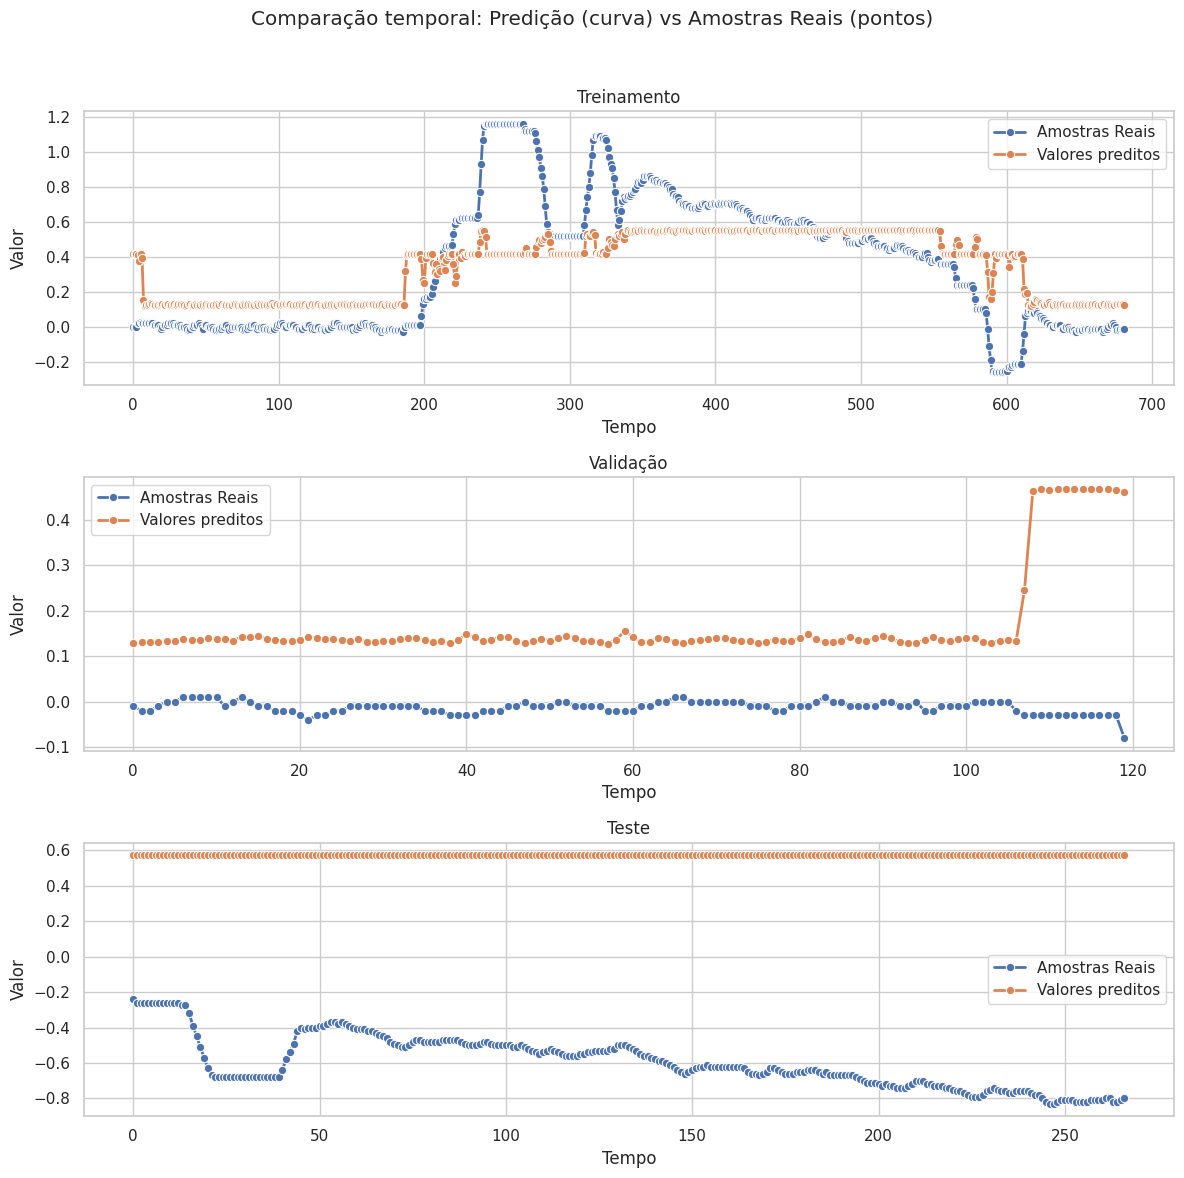

Testando combinacao4: Hidden Size=[45], regularizer=0.2, learning_rate=0.01
Shape X (batch, time_steps, features): (682, 2, 2)
Shape Y (batch, output_dim): (682, 1)
Shape h0 (batch, units): (682, 45)
Shape X (batch, time_steps, features): (120, 2, 2)
Shape Y (batch, output_dim): (120, 1)
Shape h0 (batch, units): (120, 45)
Shape X (batch, time_steps, features): (267, 2, 2)
Shape Y (batch, output_dim): (267, 1)
Shape h0 (batch, units): (267, 45)
+++++++++++ [4] | 1 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
+++++++++++ [4] | 2 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
+++++++++++ [4] | 3 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
+++++++++++ [4] | 4 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
4/4 ━━━━━

,r2_training,mse_training,mape_training,rmse_training,r2_test,mse_test,mape_test,rmse_test,r2_val,mse_val,mape_val,rmse_val
model_5_0,0.500814,0.071062,5.212604e+13,0.266575,-30.624475,0.688937,1.384586,0.830022,-148.655527,0.026663,9.877637e+13,0.163287
model_3_0,0.501502,0.070964,4.690684e+13,0.266391,-67.410346,1.490314,2.107017,1.220784,-143.136177,0.025679,9.205896e+13,0.160247


DataFrame salvo em ./content/results/metrics_5


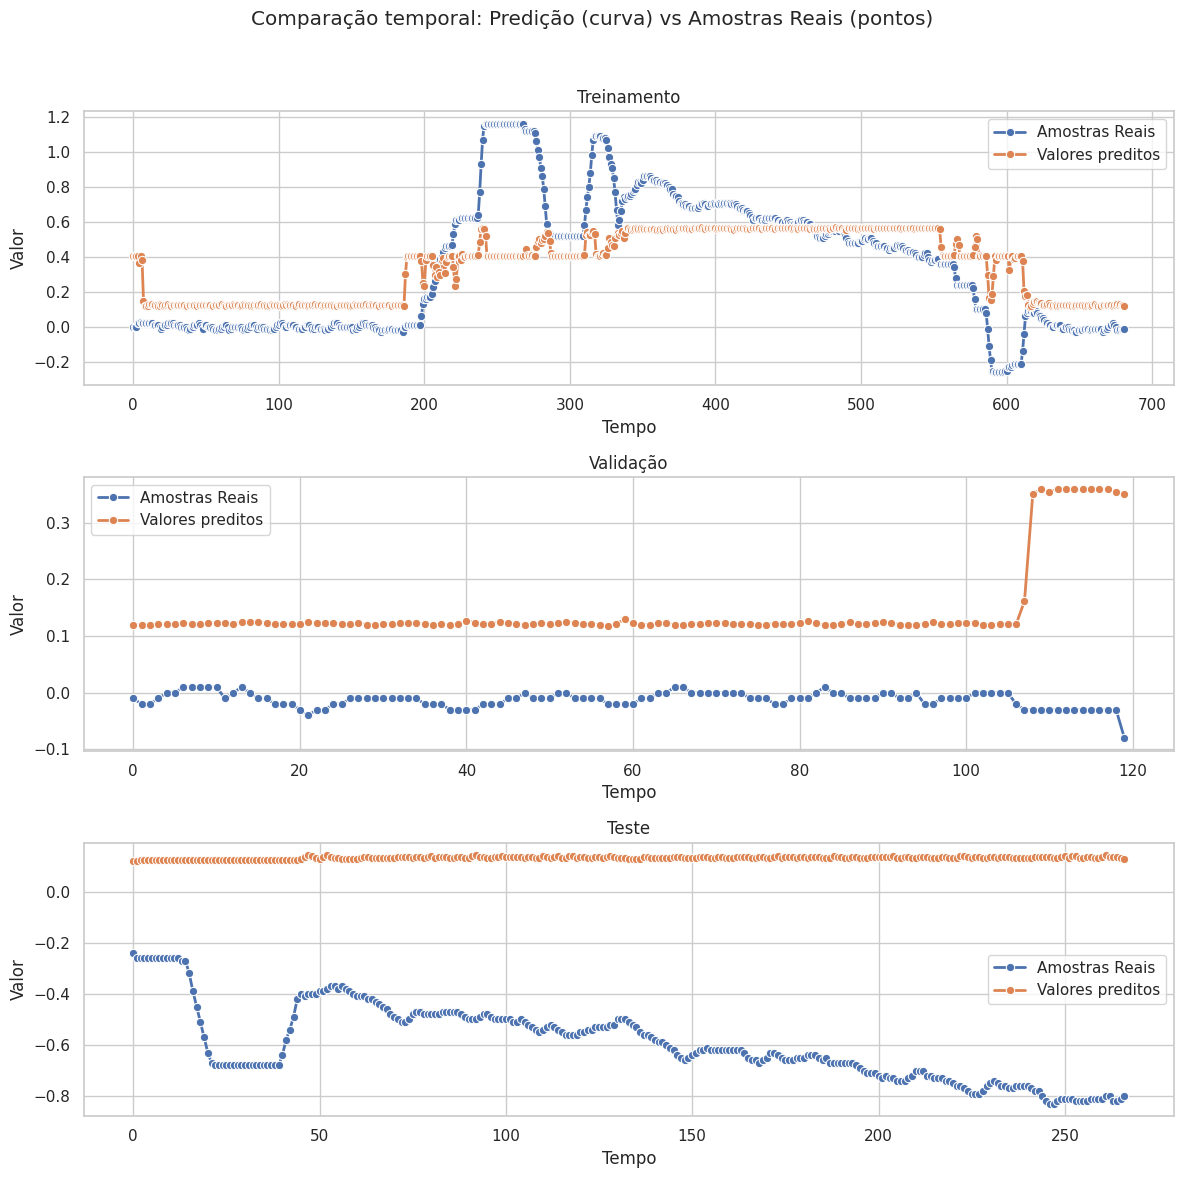

Testando combinacao6: Hidden Size=[55], regularizer=0.2, learning_rate=0.01
Shape X (batch, time_steps, features): (682, 2, 2)
Shape Y (batch, output_dim): (682, 1)
Shape h0 (batch, units): (682, 55)
Shape X (batch, time_steps, features): (120, 2, 2)
Shape Y (batch, output_dim): (120, 1)
Shape h0 (batch, units): (120, 55)
Shape X (batch, time_steps, features): (267, 2, 2)
Shape Y (batch, output_dim): (267, 1)
Shape h0 (batch, units): (267, 55)
+++++++++++ [6] | 1 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
+++++++++++ [6] | 2 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
+++++++++++ [6] | 3 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
+++++++++++ [6] | 4 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━

,r2_training,mse_training,mape_training,rmse_training,r2_test,mse_test,mape_test,rmse_test,r2_val,mse_val,mape_val,rmse_val
model_5_0,0.500814,0.071062,5.212604e+13,0.266575,-30.624475,0.688937,1.384586,0.830022,-148.655527,0.026663,9.877637e+13,0.163287
model_3_0,0.501502,0.070964,4.690684e+13,0.266391,-67.410346,1.490314,2.107017,1.220784,-143.136177,0.025679,9.205896e+13,0.160247
model_6_0,0.505257,0.070429,5.675815e+13,0.265386,-56.600154,1.254815,1.902454,1.120185,-187.845530,0.033645,1.103624e+14,0.183425


DataFrame salvo em ./content/results/metrics_6


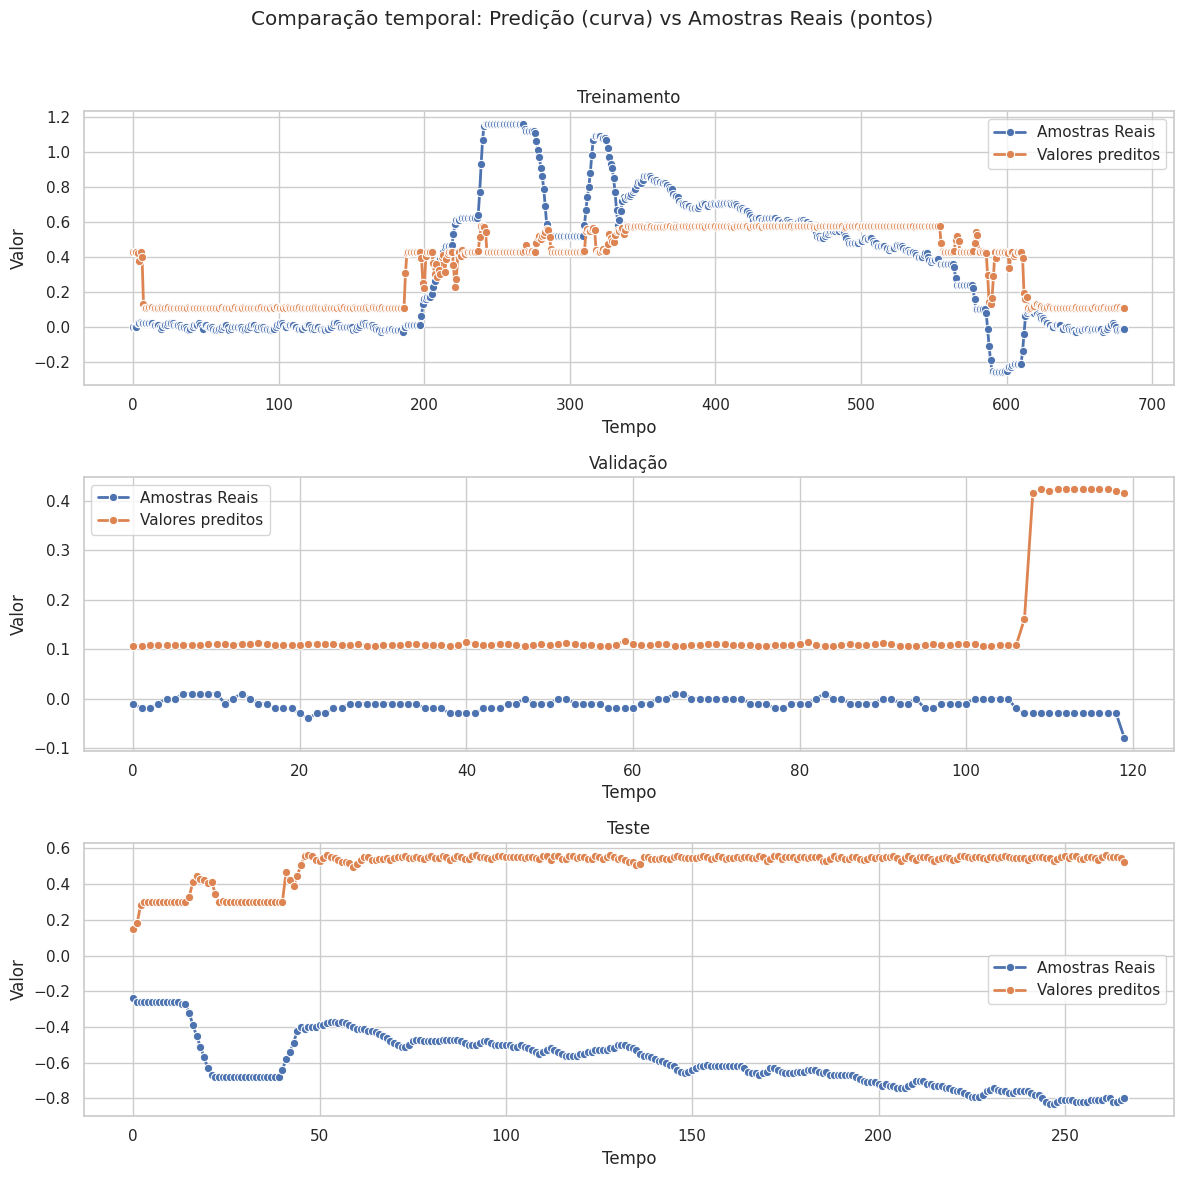

: 

In [ ]:
Valuer.Evaluate(hidden_sizes = [[30], [35], [40], [45], [50], [55]],
            regularizers=[0.2],
            learning_rate=[0.01],
            run_times = 10, 
            boundarie = 0.5,
            sort_by = 'r2_training',
) 